### Indlæsning af data og biblioteker

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col

# if libaries are not installed, run the following command in terminal:
# pip install pandas numpy seaborn matplotlib statsmodels

In [2]:
odr = pd.read_csv("data/age-dependency-ratio-old.csv")
rd = pd.read_csv("data/research-spending-gdp.csv")
internet = pd.read_csv("data/share-of-individuals-using-the-internet.csv")
gdp_pc_long = pd.read_csv("data/gdp-per-capita-worldbank.csv")

In [3]:
odr = odr.rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "Age dependency ratio, old (% of working-age population)": "odr"
})

rd = rd.rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "Research and development expenditure (% of GDP)": "rd"
})

internet = internet.rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "Share of the population using the Internet": "internet_use"
})

gdp_pc_long = gdp_pc_long.rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "GDP per capita": "gdppc",
})

In [4]:
start = 2001
end = 2020

lagged_odr = odr.copy()

for df in [odr, gdp_pc_long, internet, rd]:
    df["year"] = pd.to_numeric(df["year"], errors="coerce")

odr = odr[(odr["year"] >= start) & (odr["year"] <= end)]
gdp_pc_long = gdp_pc_long[(gdp_pc_long["year"] >= start) & (gdp_pc_long["year"] <= end)]
internet = internet[(internet["year"] >= start) & (internet["year"] <= end)]
rd = rd[(rd["year"] >= start) & (rd["year"] <= end)]

### Merge data

In [5]:
panel = internet[["country", "code", "year", "internet_use"]].merge(
    odr[["code", "year", "odr"]],
    on=["code", "year"],
    how="inner"
)

panel = panel.merge(
    rd[["code", "year", "rd"]],
    on=["code", "year"],
    how="inner"
)

panel = panel.merge(
    gdp_pc_long[["code", "year", "gdppc"]],
    on=["code", "year"],
    how="inner"
)

panel["log_gdppc"] = np.log(panel["gdppc"])
panel["log_internet_use"] = np.log(panel["internet_use"])

print("Number of unique countries:", panel["code"].nunique())
print("Number of unique years:", panel["year"].nunique())

Number of unique countries: 148
Number of unique years: 20


### Balancer data

In [6]:
# Remove to countries that do not have data for all years
years_per_country = panel.groupby(["country", "code"])["year"].nunique().reset_index()
years_per_country = years_per_country.rename(columns={"year": "n_years"})
eligible_codes = years_per_country[years_per_country["n_years"] == 20]["code"]
panel_balanced = panel[panel["code"].isin(eligible_codes)].copy()


In [7]:
print("Number of unique countries:", panel_balanced["code"].nunique())
print("Number of unique years:", panel_balanced["year"].nunique())

print("\nCheck for NaN values:")
print(panel_balanced[["internet_use", "odr", "rd", "gdppc"]].isna().sum())

Number of unique countries: 50
Number of unique years: 20

Check for NaN values:
internet_use    0
odr             0
rd              0
gdppc           0
dtype: int64


### Estimering af model

In [8]:
# kopi af det færdige balanced panel
df_est = panel_balanced.copy()

# estimation
model1= smf.ols(
    "log_internet_use ~ odr + C(code) + C(year)",
    data=df_est
)

results1 = model1.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)


# estimation
model3 = smf.ols(
    "log_internet_use ~ odr + log_gdppc + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)




In [9]:
results = summary_col(
    [results1, results3],
    stars=True,
    model_names=['ODR', '+ log(GDPpc)'],
    regressor_order=['odr', 'log_gdppc'],
    drop_omitted=True,
    info_dict={
        'Observationer': lambda x: f"{int(x.nobs)}",
        'Antal lande': lambda x: f"{x.nunique['code']}",
    }
)

#print the model
print("log (Internet) ~ odr + log_gdppc + FE(code) + FE(year)")
print(results)

log (Internet) ~ odr + log_gdppc + FE(code) + FE(year)

                  ODR     + log(GDPpc)
--------------------------------------
odr            -0.1482*** -0.1298***  
               (0.0391)   (0.0367)    
log_gdppc                 1.1059***   
                          (0.2896)    
R-squared      0.8668     0.8895      
R-squared Adj. 0.8570     0.8812      
Antal lande                           
Observationer  1000       1000        
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


### Model med Researh and Development

In [10]:
# kopi af det færdige balanced panel
df_est = panel_balanced.copy()

# estimation
model1= smf.ols(
    "log_internet_use ~ odr + C(code) + C(year)",
    data=df_est
)

results1 = model1.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

# estimation
model3 = smf.ols(
    "log_internet_use ~ odr + log_gdppc + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

# estimation
model2 = smf.ols(
    "log_internet_use ~ odr + log_gdppc + rd + C(code) + C(year)",
    data=df_est
)

results2 = model2.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

results = summary_col(
    [results1, results3,results2],
    stars=True,
    model_names=['ODR', '+ log(GDPpc)','+ rd'],
    regressor_order=['odr', 'log_gdppc', 'rd'],
    drop_omitted=True,
    info_dict={
        'Observationer': lambda x: f"{int(x.nobs)}",
        'Antal lande': lambda x: f"{x.nunique['code']}",
    }
)

#print the model
print("log (Internet) ~ odr + log_gdppc + rd + FE(code) + FE(year)")
print(results)

log (Internet) ~ odr + log_gdppc + rd + FE(code) + FE(year)

                  ODR     + log(GDPpc)    + rd   
-------------------------------------------------
odr            -0.1482*** -0.1298***   -0.1179***
               (0.0391)   (0.0367)     (0.0310)  
log_gdppc                 1.1059***    1.1072*** 
                          (0.2896)     (0.2898)  
rd                                     -0.4177***
                                       (0.1193)  
R-squared      0.8668     0.8895       0.9004    
R-squared Adj. 0.8570     0.8812       0.8927    
Antal lande                                      
Observationer  1000       1000         1000      
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


### Opretter aggregerede dataframe

In [11]:
#make a copy of the dataframe
panel_2yr = panel_balanced.copy()

# Lav 2-års perioder
panel_2yr["period_start"] = start + 2 * ((panel_2yr["year"] - start) // 2)
panel_2yr["period_end"] = panel_2yr["period_start"] + 1

# Variabler der skal gennemsnittes
vars_to_average = [
    "gdppc",
    "odr",
    "internet_use",
    "rd",
]

# Behold kun dem der faktisk findes i datasættet
vars_to_average = [v for v in vars_to_average if v in panel_2yr.columns]

# Collapse til én række pr. land og 2-års periode
panel_2yr = (
    panel_2yr
    .groupby(["code", "country", "period_start", "period_end"], as_index=False)[vars_to_average]
    .mean()
)

# Lav evt. en year-variabel til FE
panel_2yr["year"] = panel_2yr["period_start"]

panel_2yr["log_internet_use"] = np.log(panel_2yr["internet_use"])
panel_2yr["log_gdppc"] = np.log(panel_2yr["gdppc"])

In [12]:
#make a copy of the dataframe
panel_4yr = panel_balanced.copy()

# Lav 4-års perioder
panel_4yr["period_start"] = start + 4 * ((panel_4yr["year"] - start) // 4)
panel_4yr["period_end"] = panel_4yr["period_start"] + 3
# Behold kun dem der faktisk findes i datasættet
vars_to_average = [v for v in vars_to_average if v in panel_2yr.columns]

# Collapse til én række pr. land og 4-års periode
panel_4yr = (
    panel_4yr
    .groupby(["code", "country", "period_start", "period_end"], as_index=False)[vars_to_average]
    .mean()
)

# Lav evt. en year-variabel til FE
panel_4yr["year"] = panel_4yr["period_start"]

panel_4yr["log_internet_use"] = np.log(panel_4yr["internet_use"])
panel_4yr["log_gdppc"] = np.log(panel_4yr["gdppc"])


In [13]:
#make a copy of the dataframe
panel_5yr = panel_balanced.copy()

# Lav 5-års perioder
panel_5yr["period_start"] = start + 5 * ((panel_5yr["year"] - start) // 5)
panel_5yr["period_end"] = panel_5yr["period_start"] + 4
# Behold kun dem der faktisk findes i datasættet
vars_to_average = [v for v in vars_to_average if v in panel_2yr.columns]

# Collapse til én række pr. land og 5-års periode
panel_5yr = (
    panel_5yr
    .groupby(["code", "country", "period_start", "period_end"], as_index=False)[vars_to_average]
    .mean()
)

# Lav evt. en year-variabel til FE
panel_5yr["year"] = panel_5yr["period_start"]

panel_5yr["log_internet_use"] = np.log(panel_5yr["internet_use"])
panel_5yr["log_gdppc"] = np.log(panel_5yr["gdppc"])


### Results - Aggregerede fulde model

In [14]:
# kopi af det færdige balanced panel
df_est = panel_balanced.copy()

# estimation
model1= smf.ols(
    "log_internet_use ~ odr + rd + log_gdppc + C(code) + C(year)",
    data=df_est
)

results1 = model1.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

# kopi af det færdige balanced panel
df_est = panel_2yr.copy()

# estimation
model2 = smf.ols(
    "log_internet_use ~ odr + rd + log_gdppc + C(code) + C(year)",
    data=df_est
)

results2 = model2.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

# kopi af det færdige balanced panel
df_est = panel_4yr.copy()

# estimation
model3 = smf.ols(
    "log_internet_use ~ odr + rd + log_gdppc + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

# kopi af det færdige balanced panel
df_est = panel_5yr.copy()

# estimation
model4 = smf.ols(
    "log_internet_use ~ odr + rd + log_gdppc + C(code) + C(year)",
    data=df_est
)

results4 = model4.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)




In [15]:
results = summary_col(
    [results1, results2, results3, results4],
    stars=True,
    model_names=['1 year', '2 years', '4 years', '5 years'],
    regressor_order=['odr', 'log_gdppc', 'rd'],
    drop_omitted=True,
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
    }
)

#print the model
print("log(internet_use) ~ odr + log_gdppc + rd + FE(code) + FE(year)")
print(results)


log(internet_use) ~ odr + log_gdppc + rd + FE(code) + FE(year)

                 1 year    2 years    4 years    5 years  
----------------------------------------------------------
odr            -0.1179*** -0.1177*** -0.1171*** -0.1150***
               (0.0310)   (0.0321)   (0.0348)   (0.0350)  
log_gdppc      1.1072***  1.1249***  1.1288***  1.1538*** 
               (0.2898)   (0.2876)   (0.2927)   (0.3041)  
rd             -0.4177*** -0.4268*** -0.4479*** -0.4557***
               (0.1193)   (0.1263)   (0.1398)   (0.1470)  
R-squared      0.9004     0.9065     0.9144     0.9205    
R-squared Adj. 0.8927     0.8934     0.8896     0.8901    
N              1000       500        250        200       
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


In [16]:
# kopi af det færdige balanced panel
df_est = panel_balanced.copy()

# estimation
model1= smf.ols(
    "log_internet_use ~ odr + log_gdppc + C(code) + C(year)",
    data=df_est
)

results1 = model1.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

# kopi af det færdige balanced panel
df_est = panel_2yr.copy()

# estimation
model2 = smf.ols(
    "log_internet_use ~ odr  + log_gdppc + C(code) + C(year)",
    data=df_est
)

results2 = model2.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

# kopi af det færdige balanced panel
df_est = panel_4yr.copy()

# estimation
model3 = smf.ols(
    "log_internet_use ~ odr + log_gdppc + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

# kopi af det færdige balanced panel
df_est = panel_5yr.copy()

# estimation
model4 = smf.ols(
    "log_internet_use ~ odr + log_gdppc + C(code) + C(year)",
    data=df_est
)

results4 = model4.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)


In [17]:
results = summary_col(
    [results1, results2, results3, results4],
    stars=True,
    model_names=['1 year', '2 years', '4 years', '5 years'],
    regressor_order=['odr', 'log_gdppc'],
    drop_omitted=True,
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
    }
)

#print the model
print("log(internet_use) ~ odr + log_gdppc + FE(code) + FE(year)")
print(results)


log(internet_use) ~ odr + log_gdppc + FE(code) + FE(year)

                 1 year    2 years    4 years    5 years  
----------------------------------------------------------
odr            -0.1298*** -0.1301*** -0.1306*** -0.1285***
               (0.0367)   (0.0380)   (0.0414)   (0.0419)  
log_gdppc      1.1059***  1.1205***  1.1180***  1.1436*** 
               (0.2896)   (0.2898)   (0.2983)   (0.3105)  
R-squared      0.8895     0.8952     0.9025     0.9081    
R-squared Adj. 0.8812     0.8809     0.8748     0.8738    
N              1000       500        250        200       
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


## Deskriptiv statistik

In [18]:
#print antallet af lande i panel_balanced
print("Antal lande i panel_balanced:", panel_balanced["code"].nunique())


Antal lande i panel_balanced: 50


In [19]:
#print deskriptiv statistik
descriptive_stats = panel_balanced[["internet_use", "odr", "gdppc"]].describe()
print(descriptive_stats.round(2))

       internet_use      odr      gdppc
count       1000.00  1000.00    1000.00
mean          56.51    19.76   39003.98
std           27.01     8.29   23686.11
min            0.60     2.28    3188.81
25%           35.27    12.01   21575.93
50%           62.82    20.33   35861.78
75%           78.82    25.91   52719.06
max           99.60    48.98  174569.52


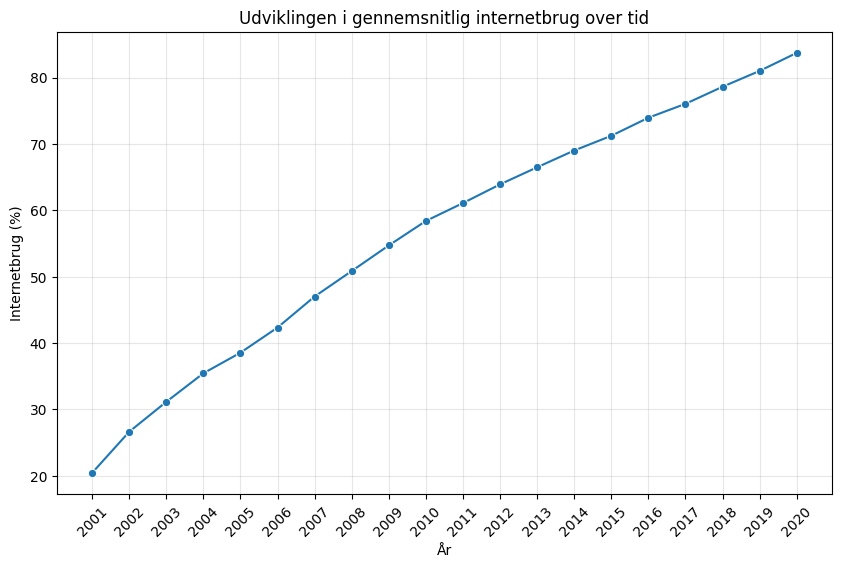

In [20]:
avg_internet_by_year = (
    panel_balanced
    .groupby("year")["internet_use"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=avg_internet_by_year,
    x="year",
    y="internet_use",
    marker="o"
)

plt.title("Udviklingen i gennemsnitlig internetbrug over tid")
plt.xlabel("År")
plt.ylabel("Internetbrug (%)")

plt.xticks(avg_internet_by_year["year"], rotation=45)

plt.grid(True, alpha=0.3)

plt.show()